In [2]:
import pandas as pd

df = pd.read_csv("../data/master_ecommerce.csv")

KPI 1: Total Revenue

In [5]:
total_revenue = df["payment_value"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $19,529,614.54


KPI: 2 Total Orders


In [6]:
total_orders = df["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 95,122


KPI: 3 Total Customers


In [7]:
total_customers = df["customer_unique_id"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 92,075


KPI: 4 Average Order Value (AOV)

In [8]:
aov = total_revenue / total_orders

print(f"Average Order Value: ${aov:.2f}")

Average Order Value: $205.31


KPI: 5 Revenue per Customer

In [9]:
revenue_per_customer = total_revenue / total_customers

print(f"Revenue per Customer: ${revenue_per_customer:.2f}")

Revenue per Customer: $212.11


In [10]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

In [11]:
monthly_revenue = (
    df.groupby(
        pd.Grouper(
            key = "order_purchase_timestamp",
            freq = "M"
        )
    )["payment_value"].sum().reset_index()
)

C:\Users\thiru\AppData\Local\Temp\ipykernel_3476\1732188463.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


In [12]:
monthly_revenue.head()

,order_purchase_timestamp,payment_value
0,2016-10-31,61651.02
1,2016-11-30,0.00
2,2016-12-31,19.62
3,2017-01-31,172487.07
4,2017-02-28,313470.32


Revenue Trend Visualization

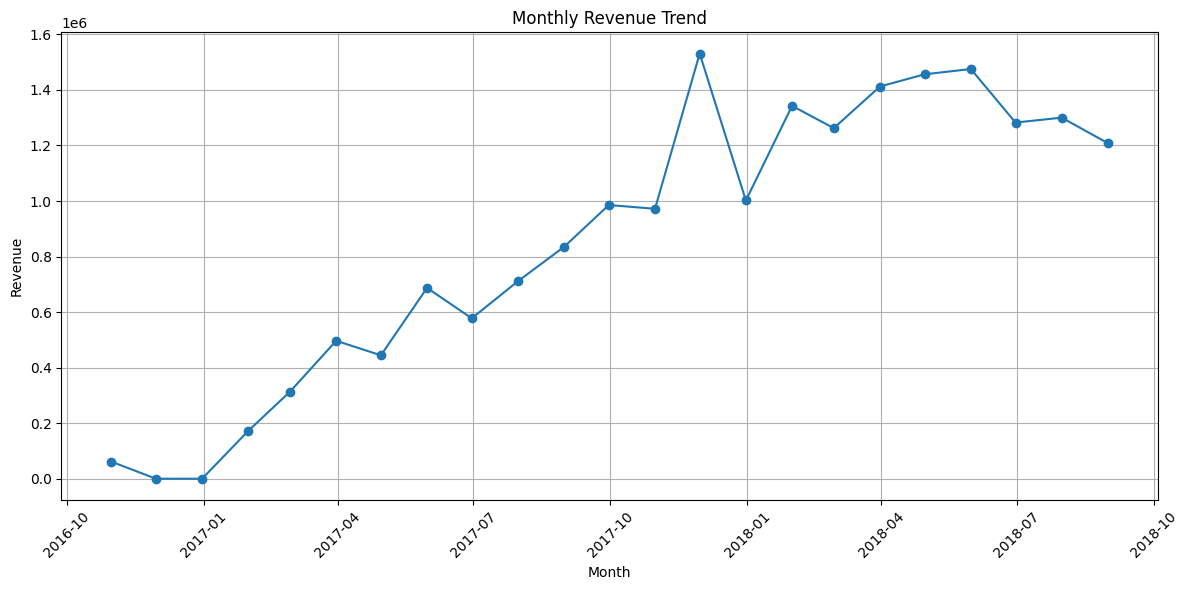

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["order_purchase_timestamp"],
    monthly_revenue["payment_value"],
    marker = "o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Business Insight

1. Revenue Growth

Revenue increased significantly from 2017 to 2018, indicating successful business expansion.

2. Seasonality

Strong revenue spike observed during Nov-Dec 2017, suggesting the impact of holiday and promotional campaigns.

3. Customer Demand

Revenue remained consistently high throughout 2018, showing improved customer retention and repeat purchases.

4. Strategic Recommendation

Increase marketing and inventory allocation before Q4 to capitalize on seasonal demand spikes.

Top 10 States by Revenue

In [17]:
state_revenue = (df.groupby("customer_state")["payment_value"].sum().sort_values(ascending=False).head(10))

print(state_revenue)

customer_state
SP    7313063.33
RJ    2657658.46
MG    2257817.15
RS    1090171.76
PR    1020152.26
BA     762368.88
SC     758552.01
GO     482929.45
DF     418039.12
ES     396343.83
Name: payment_value, dtype: float64


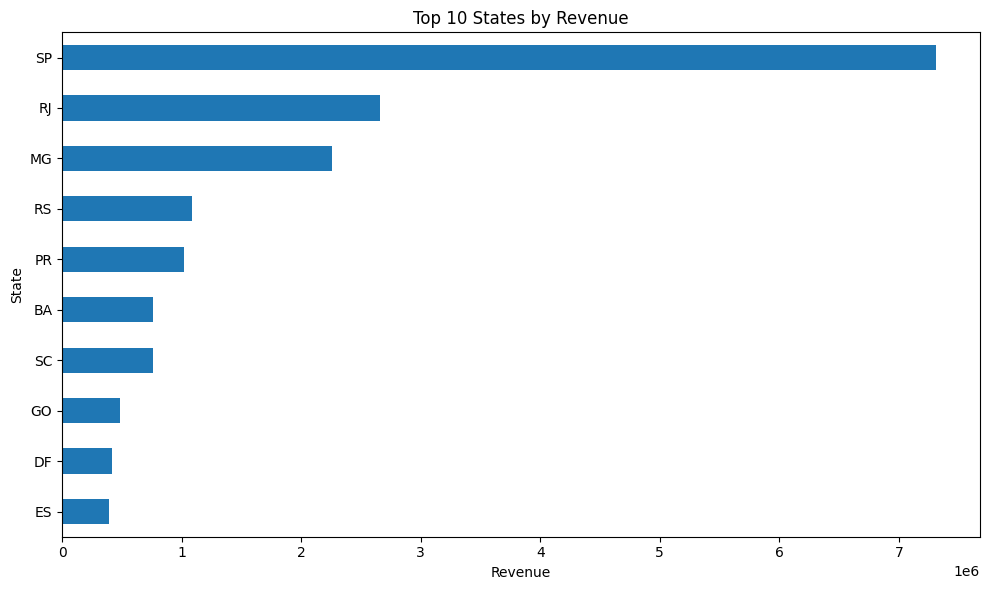

In [25]:
plt.figure(figsize=(10,6))

state_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")

plt.tight_layout()
plt.show()

Business Insights:

1. São Paulo is the highest revenue-generating state,
   contributing a substantial share of overall sales.

2. Revenue is heavily concentrated in a few states,
   indicating dependency on key regional markets.

3. Rio de Janeiro and Minas Gerais are strong secondary
   markets with significant growth potential.

4. Marketing and logistics investments should focus on
   high-performing states while exploring expansion
   opportunities in underpenetrated regions.

Top Product Categories

In [27]:
top_categories = (
    df.groupby("product_category_name")["payment_value"].sum().sort_values(ascending=False).head(10).reset_index())

print(top_categories)

    product_category_name  payment_value
0         cama_mesa_banho     1692557.09
1            beleza_saude     1620684.04
2  informatica_acessorios     1549252.47
3        moveis_decoracao     1393972.04
4      relogios_presentes     1387046.31
5           esporte_lazer     1349158.47
6   utilidades_domesticas     1069787.97
7              automotivo      833610.84
8      ferramentas_jardim      810460.70
9              cool_stuff      744339.94


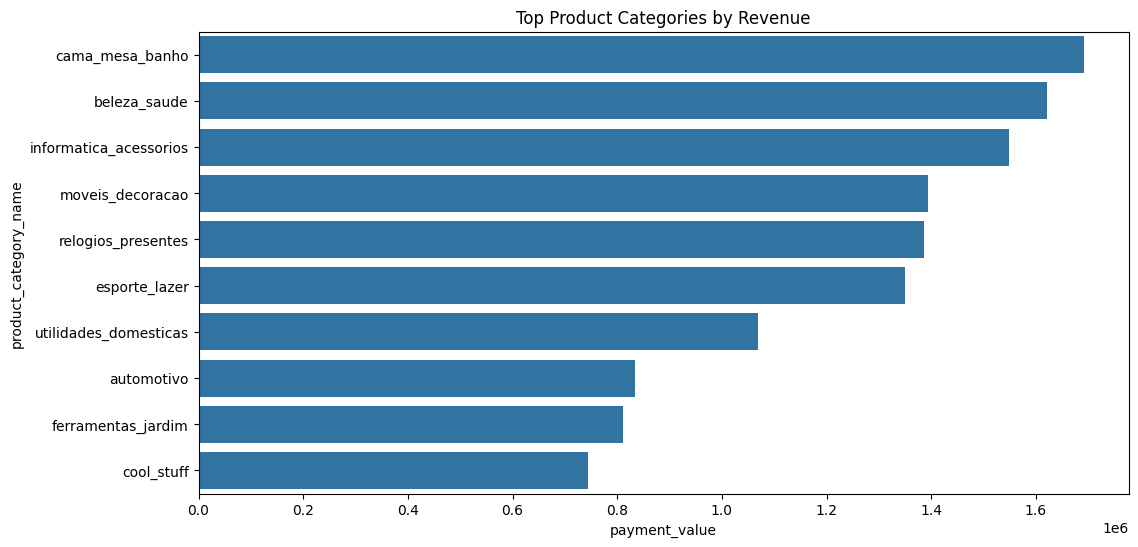

In [28]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    data = top_categories,
    x = "payment_value",
    y = "product_category_name"
)

plt.title("Top Product Categories by Revenue")
plt.show()

Business Insights

| Category               | Interpretation                                 |
| ---------------------- | ---------------------------------------------- |
| cama_mesa_banho        | Home & bath products are major revenue drivers |
| beleza_saude           | Health & beauty has strong demand              |
| informatica_acessorios | Technology accessories are popular             |
| moveis_decoracao       | Home furnishing category performs well         |
| relogios_presentes     | Watches and gifts contribute significantly     |


In [30]:
category_orders = (df.groupby("product_category_name")["order_id"].nunique().sort_values(ascending=False).head(10).reset_index())

print(category_orders)

    product_category_name  order_id
0         cama_mesa_banho      9271
1            beleza_saude      8646
2           esporte_lazer      7527
3  informatica_acessorios      6529
4        moveis_decoracao      6303
5   utilidades_domesticas      5743
6      relogios_presentes      5493
7               telefonia      4092
8              automotivo      3809
9              brinquedos      3803


Number of Orders by Category

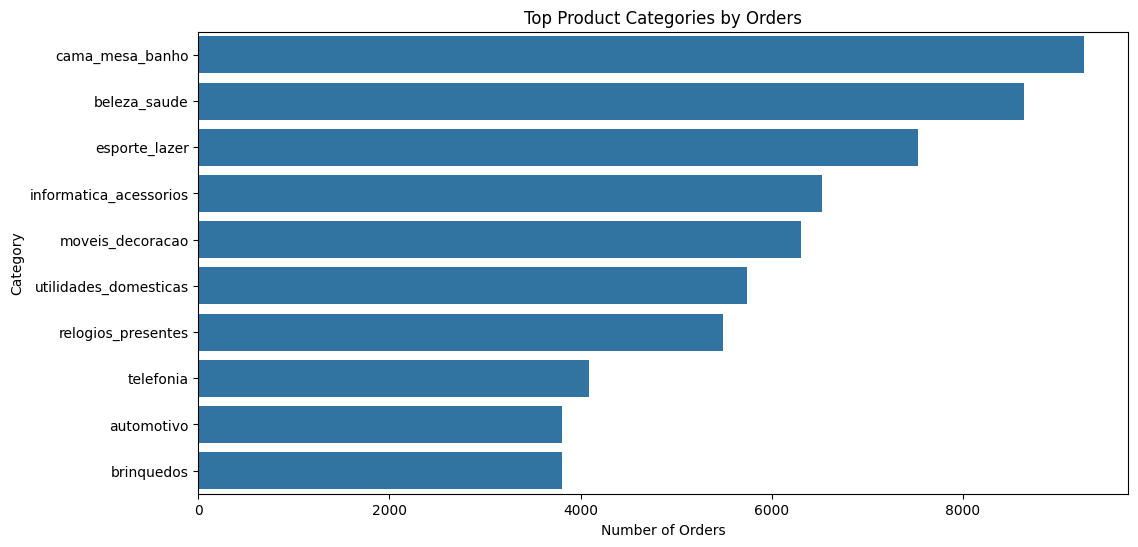

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_orders,
    x="order_id",
    y="product_category_name"
)

plt.title("Top Product Categories by Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Category")

plt.show()

Business Insight

1. Home & Bath Products Lead Customer Demand

    cama_mesa_banho (Bed, Bath & Table) recorded the highest number of orders.
    This category represents a core demand segment and contributes significantly to overall sales volume.

2. Beauty & Health Shows Strong Market Performance

    beleza_saude ranks second in total orders.
    The consistent demand indicates strong customer interest in personal care and wellness products.

3. Lifestyle Categories Drive Engagement

    Categories such as esporte_lazer (Sports & Leisure) and moveis_decoracao (Furniture & Decor) attract substantial order volumes.
    These segments reflect consumer spending on lifestyle and home improvement products.

4. Technology Products Maintain Steady Demand

    informatica_acessorios (Computer Accessories) remains among the top-performing categories.
    This suggests stable demand for technology-related products and accessories.

5. Diversified Product Portfolio

    Orders are distributed across multiple categories rather than concentrated in a single segment.
    This diversification reduces business risk and improves revenue stability.


Business Recommendations

1. Inventory Planning
Maintain higher inventory levels for Home & Bath, Beauty & Health, and Sports & Leisure categories to prevent stockouts.

2. Marketing Strategy
Allocate marketing budgets toward high-performing categories to maximize return on investment.

3. Cross-Selling Opportunities
Bundle complementary products from Home & Bath and Furniture & Decor categories to increase average order value.

4. Category Expansion
Explore expanding product offerings within the top-performing categories to capture additional customer demand.

Executive Summary

Analysis of 95,122 completed orders revealed strong business growth between 2017 and 2018. Home & Bath, Beauty & Health, and Sports & Leisure emerged as the most demanded product categories, while São Paulo generated the highest regional revenue. These findings highlight opportunities for inventory optimization, targeted marketing campaigns, and regional expansion strategies.